In [10]:
# Python packages
import scanpy as sc
import anndata as ad
import scib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import harmony
import scvi
import os
from os.path import join
import warnings
import itertools
import scipy
import torch

warnings.filterwarnings('ignore', message='.*OldFormatWarning.*', module='anndata')
# R interface
from rpy2.robjects import pandas2ri
from rpy2.robjects import r
import rpy2.rinterface_lib.callbacks
import anndata2ri

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:368: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '
/tmp/ipykernel_808855/373701847.py:26: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [11]:
%%R
# R packages
.libPaths(.Library)
print(.libPaths())
library(Seurat)

[1] "/home/akollot/miniforge3/envs/angl_BM2/lib/R/library"            
[2] "/gnu/store/83yfbawaqv8368iih7x69g88z7ri5w40-profile/site-library"


In [12]:
test_ad = sc.read_h5ad("/data/akalin/akollot/anglemania_benchmark/results/pbmcsca/anglemania/seurat.h5ad")
test_ad

/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/anndata/_io/specs/registry.py:256: OldFormatWarning: Element '/layers' was written without encoding metadata.
  return self.callback(read_func, elem.name, elem, iospec=iospec)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/anndata/_io/specs/registry.py:256: OldFormatWarning: Element '/layers/SCT' was written without encoding metadata.
  return self.callback(read_func, elem.name, elem, iospec=iospec)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/anndata/_io/utils.py:207: OldFormatWarning: Element '/obs/orig.ident' was written without encoding metadata.
  return func(*args, **kwargs)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/anndata/_io/utils.py:207: OldFormatWarning: Element '/obs/nCount_RNA' was written without encoding metadata.
  return func(*args, **kwargs)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/anndata/_io/utils.py:207

AnnData object with n_obs × n_vars = 24424 × 2004
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'X_index', 'nGene', 'nUMI', 'percent.mito', 'Cluster', 'CellType', 'Experiment', 'Method', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'nCount_SCT', 'nFeature_SCT'
    var: 'features', 'SCT_features'
    layers: 'RNA', 'SCT'

In [17]:
counts = test_ad.X.copy()
meta = test_ad.obs.copy()
cell_names = test_ad.obs_names
gene_names = test_ad.var_names
adata = ad.AnnData(counts)
adata.obs_names = cell_names
adata.var_names = gene_names
adata.obs = meta
adata

AnnData object with n_obs × n_vars = 24424 × 2004
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'X_index', 'nGene', 'nUMI', 'percent.mito', 'Cluster', 'CellType', 'Experiment', 'Method', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'nCount_SCT', 'nFeature_SCT'

In [18]:
sc.tl.pca(adata)

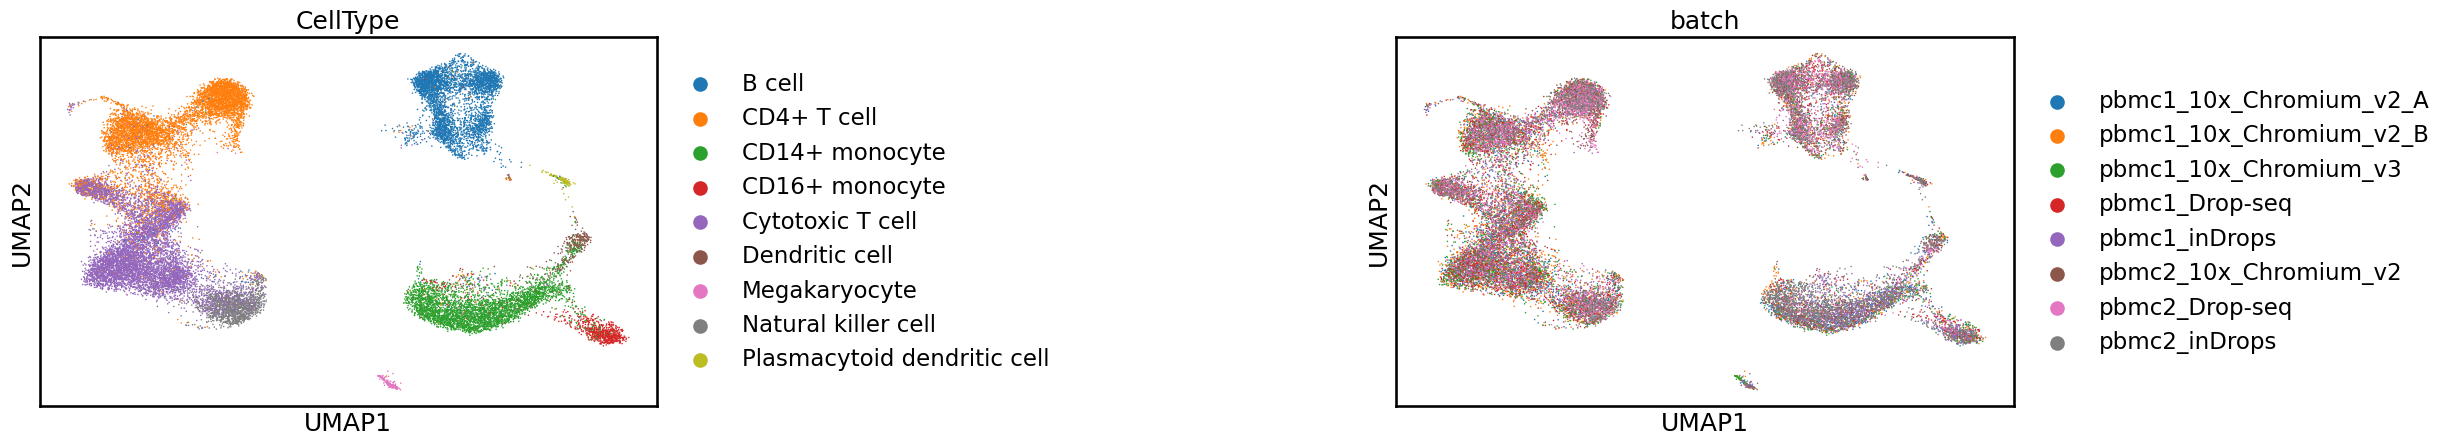

In [19]:
sc.pp.neighbors(adata,
                n_neighbors=15,
                use_rep = 'X_pca')
label_key = "CellType"
batch_key = "batch"
sc.tl.umap(adata)
sc.pl.umap(adata, color=[label_key, batch_key], wspace=1)

In [20]:
adata.write_h5ad("/data/akalin/akollot/anglemania_benchmark/results/pbmcsca/anglemania/new_seurat.h5ad")
adata = sc.read_h5ad("/data/akalin/akollot/anglemania_benchmark/results/pbmcsca/anglemania/new_seurat.h5ad")

adata

AnnData object with n_obs × n_vars = 24424 × 2004
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'X_index', 'nGene', 'nUMI', 'percent.mito', 'Cluster', 'CellType', 'Experiment', 'Method', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'nCount_SCT', 'nFeature_SCT'
    uns: 'CellType_colors', 'batch_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
test_ad.write_h5ad("/data/akalin/akollot/anglemania_benchmark/results/pbmcsca/anglemania/seurat.h5ad")

# Load data

In [39]:
h5ad_file = "/local/Projects/AAkalin_Neuroblastoma/data/PBMC/Hao_Satija_Cell_2021_PBMC_SeuratPaper/pbmc_multimodal.h5ad"
label_key = "celltype.l3"
batch_key = "orig.ident"
outfile = "./test.ipynb"
save_session = True
## Provide these parameters through papermill interface
h5ad_file = h5ad_file
label_key = label_key
batch_key = batch_key
save_session = save_session

In [40]:
adata = sc.read_h5ad(h5ad_file)
adata.obs.head()

,nCount_ADT,nFeature_ADT,nCount_RNA,nFeature_RNA,orig.ident,lane,donor,time,celltype.l1,celltype.l2,celltype.l3,Phase,nCount_SCT,nFeature_SCT,ident
L1_AAACCCAAGAAACTCA,7430.0,221,10823.0,2915,P2_7,L1,P2,7,Mono,CD14 Mono,CD14 Mono,G1,6380.0,2548,CD14 Mono
L1_AAACCCAAGACATACA,5949.0,211,5864.0,1617,P1_7,L1,P1,7,CD4 T,CD4 TCM,CD4 TCM_1,G1,5693.0,1615,CD4 TCM_1
L1_AAACCCACAACTGGTT,6547.0,217,5067.0,1381,P4_3,L1,P4,3,CD8 T,CD8 Naive,CD8 Naive,S,5066.0,1379,CD8 Naive
L1_AAACCCACACGTACTA,3508.0,207,4786.0,1890,P3_7,L1,P3,7,NK,NK,NK_2,G1,4984.0,1889,NK_2
L1_AAACCCACAGCATACT,6318.0,219,6505.0,1621,P4_7,L1,P4,7,CD8 T,CD8 Naive,CD8 Naive,G1,5854.0,1620,CD8 Naive


In [41]:
from scipy.sparse import csr_matrix
adata.X = csr_matrix(adata.X)
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["logcounts"] = adata.X.copy()
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, flavor="seurat_v3", batch_key=batch_key
)

scib.preprocessing.scale_batch(adata, batch=batch_key)
sc.tl.pca(adata)
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata_hvg


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/utils.py:72: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  return anndata.AnnData.concatenate(*adata_list, **kwargs)
/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/scib/preprocessing.py:388: ImplicitModificationWarning: Setting element `.layers['logcounts']` of view, initializing view as actual.
  adata_scaled.layers[key] = tmp[key]


AnnData object with n_obs × n_vars = 161764 × 2000
    obs: 'nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'ident'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'X_name', 'log1p', 'hvg', 'pca'
    obsm: 'PCA', 'SPCA', 'UMAP', 'WNN.UMAP', 'X_pca'
    varm: 'PCs'
    layers: 'logcounts', 'counts'

In [42]:
adata.obsm["X_pca"]

array([[ 1.31009216e+01, -1.10259843e+00,  1.72152388e+00, ...,
        -1.03617799e+00,  9.88184988e-01, -5.39979994e-01],
       [-9.13360882e+00, -3.61546612e+00, -3.27890062e+00, ...,
        -3.39060016e-02, -6.68830514e-01, -8.24305117e-01],
       [-9.63342857e+00, -3.92287087e+00, -2.35563946e+00, ...,
        -1.11319721e+00,  3.93675417e-01,  1.30695522e+00],
       ...,
       [-4.43680429e+00, -7.03486156e+00,  1.08341446e+01, ...,
         1.01106847e-02, -1.06536016e-01, -8.08264375e-01],
       [ 1.25211239e+01, -7.42444694e-01,  3.26106954e+00, ...,
         2.62406588e-01,  4.11609374e-02,  1.93815485e-01],
       [ 1.30138407e+01, -2.32042122e+00,  1.65421164e+00, ...,
        -4.85497415e-02, -3.07764292e-01,  8.16657424e-01]], dtype=float32)

In [43]:
adata_hvg.layers['counts'].toarray().shape

(161764, 2000)

In [44]:
adata_hvg.var['highly_variable']

HES4          True
TTLL10        True
TNFRSF18      True
TNFRSF4       True
LINC01134     True
              ... 
SLC7A3        True
AC073409.1    True
CDH6          True
DGKI          True
LINC01228     True
Name: highly_variable, Length: 2000, dtype: bool

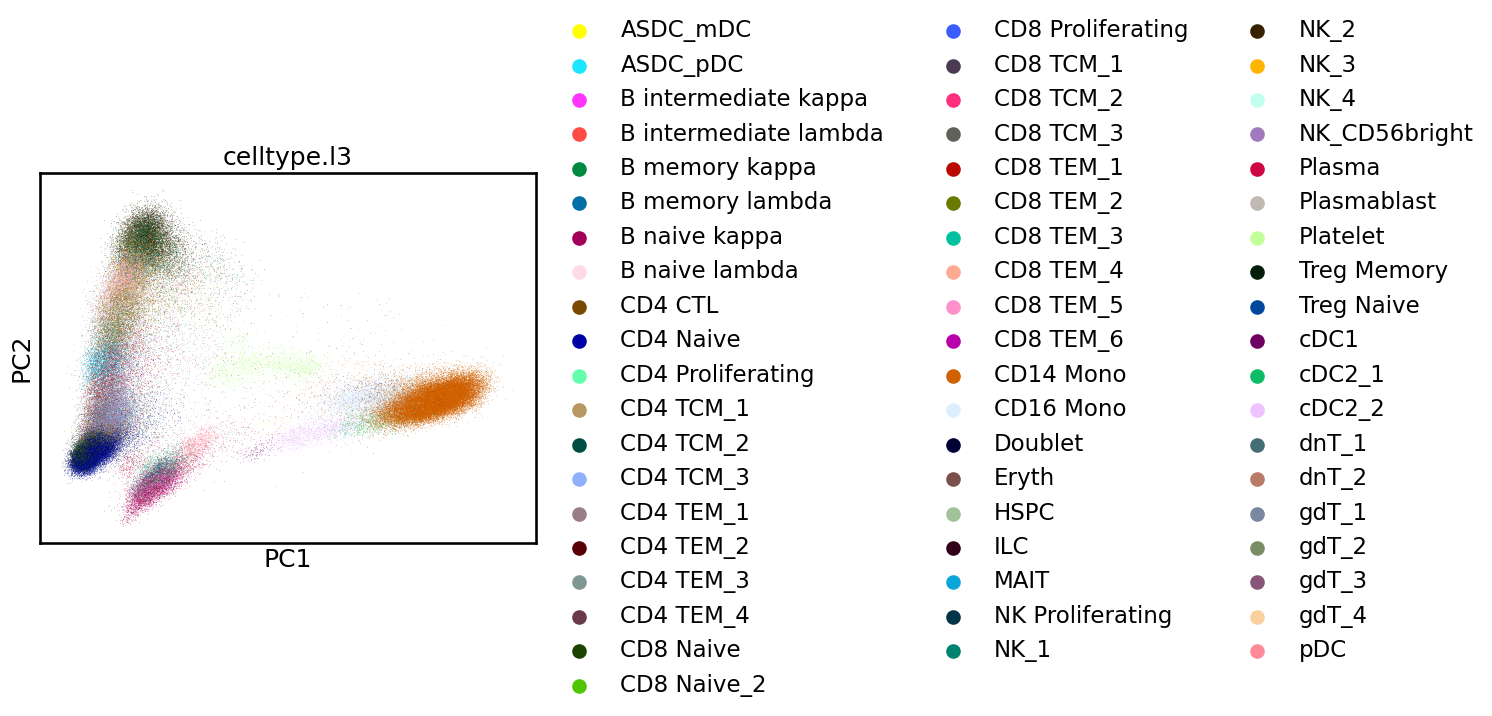

In [45]:
sc.pl.pca(adata_hvg, color = label_key)

In [46]:
# adata_hvg.write_h5ad("/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_hvg.h5ad")

In [47]:
adata_seurat_angl = adata.copy() # full dataset, not only HVGs
# Convert categorical columns to strings
adata_seurat_angl.obs[batch_key] = adata_seurat_angl.obs[batch_key].astype(str)
adata_seurat_angl.obs[label_key] = adata_seurat_angl.obs[label_key].astype(str)
# Delete uns as this can contain arbitrary objects which are difficult to convert
del adata_seurat_angl.uns
adata_seurat_angl

AnnData object with n_obs × n_vars = 161764 × 20729
    obs: 'nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'ident'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    obsm: 'PCA', 'SPCA', 'UMAP', 'WNN.UMAP', 'X_pca'
    varm: 'PCs'
    layers: 'logcounts', 'counts'

In [48]:
%%R -i adata_seurat_angl
seurat_angl <- as.Seurat(adata_seurat_angl, counts = "counts", data = "logcounts")
seurat_angl <- RenameAssays(seurat_angl, 
                assay.name = "originalexp", 
                new.assay.name = "RNA",
                verbose = FALSE)
seurat_angl

An object of class Seurat 
20729 features across 161764 samples within 1 assay 
Active assay: RNA (20729 features, 0 variable features)
 2 layers present: counts, data
 4 dimensional reductions calculated: PCA, SPCA, UMAP, WNN.UMAP


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/rpy2/ipython/rmagic.py:990: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  displaypub.publish_display_data(


In addition: Warning messages:
1: Keys should be one or more alphanumeric characters followed by an underscore, setting key from WNN.UMAP_ to WNNUMAP_ 
2: Key ‘originalexp_’ taken, using ‘rna_’ instead 


In [50]:
%%R -i batch_key
devtools::load_all("../../anglemania/")
angl <- create_anglem(seurat_object = seurat_angl,
                      batch_key = batch_key,
                      min_cells_per_gene = 1)
angl

ℹ Loading anglemania
  |                                                  | 0 % elapsed=00s    |=========                                         | 17% elapsed=08s, remaining~40s |=================                                 | 33% elapsed=18s, remaining~37s |=========================                         | 50% elapsed=28s, remaining~28s |==================================                | 67% elapsed=38s, remaining~19s |==========================================        | 83% elapsed=47s, remaining~09s |==================================================| 100% elapsed=57s, remaining~00s
Anglem object
--------------
Dataset key: NA 
Batch key: orig.ident 
Number of datasets: 1 
Total number of batches: 24 
Batches (showing first 5):
P2_7, P1_7, P4_3, P3_7, P4_7 , ...
Number of intersected genes: 14414 
Intersected genes (showing first 10):
AL669831.5, LINC00115, FAM41C, NOC2L, KLHL17, PLEKHN1, HES4, ISG15, AGRN, C1orf159 , ...
Min cells per gene: 1 


No dataset_key specified.
 Assuming that all samples belong to the same dataset and are separated by batch_key: orig.ident
Extracting count matrices...
Filtering each batch to at least 1 cells per gene...
Using the intersection of filtered genes from all batches...
Number of genes in intersected set: 14414


In [65]:
import pynetcor
from pynetcor.cor import corrcoef
from pynetcor.cor import chunked_corrcoef
matrix = adata_hvg.X.T.toarray()

cor_results = chunked_corrcoef(matrix)


In [70]:
for i in cor_results:
    print(i)    

[[ 1.00000000e+00 -1.24808539e-03 -5.95937372e-03 ...  4.98492032e-04
   2.96074338e-03 -1.37290118e-03]
 [-1.24808539e-03  1.00000000e+00  7.41229552e-02 ... -2.06999216e-04
  -1.91728139e-04 -1.94253726e-04]
 [-5.95937372e-03  7.41229552e-02  1.00000000e+00 ... -1.33447376e-03
   8.12545431e-04 -1.25230668e-03]
 ...
 [-4.43683665e-02  2.43209555e-03 -2.74334906e-02 ... -2.71498263e-03
  -2.51468859e-03  8.12419709e-04]
 [-5.14520032e-03  5.28716784e-03 -2.08672981e-03 ... -2.84090170e-04
  -2.63131815e-04 -2.66597986e-04]
 [ 9.33175434e-03  1.40836916e-03  4.20178848e-03 ... -2.54734756e-04
  -2.35942057e-04 -2.39050063e-04]]
[[ 2.31450819e-01 -1.19806484e-02 -7.98656471e-02 ...  5.58094796e-04
   2.79338450e-03  4.15249059e-04]
 [-4.34568314e-03 -2.49025445e-03 -1.09090604e-02 ...  1.10822772e-02
  -3.76638710e-04  9.52907224e-03]
 [-4.01290814e-03 -8.58325553e-04 -5.16945048e-03 ... -1.40157426e-04
  -1.29817509e-04 -1.31527563e-04]
 ...
 [ 4.98492032e-04 -2.06999216e-04 -1.3344737

In [54]:
%%R
test <- matrix_list(angl)
str(test)

List of 24
 $ P2_7:Reference class 'FBM' [package "bigstatsr"] with 15 fields
  ..$ extptr      :<externalptr> 
  ..$ extptr_rw   :<externalptr> 
  ..$ nrow        : int 14414
  ..$ ncol        : int 5513
  ..$ type        : Named int 8
  .. ..- attr(*, "names")= chr "double"
  ..$ backingfile : chr "/tmp/Rtmpb8Zno6/file30d1fa7f39ad36.bk"
  ..$ is_read_only: logi FALSE
  ..$ address     :<externalptr> 
  ..$ address_rw  :<externalptr> 
  ..$ bk          : chr "/tmp/Rtmpb8Zno6/file30d1fa7f39ad36.bk"
  ..$ rds         : chr "/tmp/Rtmpb8Zno6/file30d1fa7f39ad36.rds"
  ..$ is_saved    : logi FALSE
  ..$ type_chr    : chr "double"
  ..$ type_size   : int 8
  ..$ file_size   : num 6.36e+08
  ..and 22 methods, of which 8 are  possibly relevant:
  ..  add_columns, bm, bm.desc, check_dimensions, check_write_permissions,
  ..  initialize, save, show#envRefClass
 $ P1_7:Reference class 'FBM' [package "bigstatsr"] with 15 fields
  ..$ extptr      :<externalptr> 
  ..$ extptr_rw   :<externalptr> 
  

In [55]:
%%R
# bigparallelr::set_blas_ncores(16)
angl <- big_anglemanise(angl,
                        zscore_mean_threshold = 2,
                        max_n_genes = 3000,
                        zscore_sn_threshold = 3.5,
                        n_cores = 20
)

  |                                                  | 0 % elapsed=00s    |=========================                         | 50% elapsed=03m 53s, remaining~03m 53s |==================================================| 100% elapsed=06m 18s, remaining~00s


/home/akollot/miniforge3/envs/angl_BM2/lib/python3.11/site-packages/rpy2/ipython/rmagic.py:990: DeprecationWarning: The `source` parameter emit a  deprecation warning since IPython 8.0, it had no effects for a long time and will  be removed in future versions.
  displaypub.publish_display_data(


Computing correlations and transforming to z-scores...
Computing statistics...
Weighting matrix_list...
Calculating mean...
Calculating sds...
Filtering features...


In [56]:
%%R -o anglemania_genes
anglemania_genes <- extract_integration_genes(angl)

In [58]:
adata_angl = adata[:, anglemania_genes].copy()
adata_angl
adata_angl.write_h5ad("/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_angl.h5ad")

# Unintegrated data

In [ ]:
# # sc.pp.highly_variable_genes(adata)
# # sc.tl.pca(adata)
# sc.pp.neighbors(adata, use_rep = 'X_emb')
# sc.tl.umap(adata)
# adata

In [ ]:
# sc.pl.umap(adata, color=[label_key, batch_key], wspace=1)

# Select HVGs - Batch-aware feature selection

In [ ]:
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, flavor="seurat_v3", batch_key=batch_key
)
adata
adata.var

In [ ]:
n_batches = adata.var["highly_variable_nbatches"].value_counts()
ax = n_batches.plot(kind="bar")
n_batches

The first thing we notice is that most genes are not highly variable. This is typically the case but it can depend on how different the samples we are trying to integrate are. The overlap then decreases as we add more samples, with relatively few genes being highly variable in all three batches. By selecting the top 2000 genes we have selected all HVGs that are present in two or three batches and most of those that are present in one batch.

```{admonition} How many genes to use?

This is a question that doesn't have a clear answer. The authors of the **scvi-tools** package which we use below recommend between 1000 and 10000 genes but how many depends on the context including the complexity of the dataset and the number of batches. A survey from a previous best practices paper {cite}`Luecken2019-og` indicated people typically use between 1000 and 6000 HVGs in a standard analysis. While selecting fewer genes can aid in the removal of batch effects {cite}`Luecken2021-jo` (the most highly-variable genes often describe only dominant biological variation), we recommend selecting slightly too many genes rather than selecting too few and risk removing genes that are important for a rare cell type or a pathway of interest. It should however be noted that more genes will also increase the time required to run the integration methods.
```

We will create an object with just the selected genes to use for integration.

In [ ]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata_hvg

In [ ]:
adata_hvg.write_h5ad("/data/akalin/akollot/anglemania_benchmark/data/Hao_Satija_Cell_2021_PBMC/adata_hvg.h5ad")

In [ ]:
adata_hvg[0:3000,]

In [ ]:
adata_harmony = adata_hvg[0:6000].copy()

scib.integration.scvi(adata_harmony,
                         batch = batch_key
                         )
adata_harmony
# adata_harmony.write_h5ad("/data/akalin/akollot/anglemania_benchmark/data/pbmcsca/adata_harmony.h5ad")

# HVG Integration

## Seurat - Linear embedding integration using Mutual Nearest Neighbors (MNN)

In [ ]:
adata_seurat = adata_hvg.copy()
# Convert categorical columns to strings
adata_seurat.obs[batch_key] = adata_seurat.obs[batch_key].astype(str)
adata_seurat.obs[label_key] = adata_seurat.obs[label_key].astype(str)
# Delete uns as this can contain arbitrary objects which are difficult to convert
del adata_seurat.uns
adata_seurat

In [ ]:
%%R -i adata_seurat
seurat <- as.Seurat(adata_seurat, counts = "counts", data = "logcounts")
seurat

In [ ]:
%%R -i batch_key
batch_list <- SplitObject(seurat, split.by = batch_key)
batch_list

In [ ]:
%%R
anchors <- FindIntegrationAnchors(batch_list, anchor.features = rownames(seurat))
anchors

In [ ]:
%%R
integrated <- IntegrateData(anchors)
integrated

In [ ]:
%%R -o integrated_expr
# Extract the integrated expression matrix
integrated_expr <- GetAssayData(integrated)
# Make sure the rows and columns are in the same order as the original object
integrated_expr <- integrated_expr[rownames(seurat), colnames(seurat)]
# Transpose the matrix to AnnData format
integrated_expr <- t(integrated_expr)
print(integrated_expr[1:10, 1:10])

In [ ]:
adata_seurat.X = integrated_expr
adata_seurat.layers["seurat"] = integrated_expr
print(adata_seurat)
adata.X

In [ ]:
sc.tl.pca(adata_seurat)
sc.pp.neighbors(adata_seurat)
sc.tl.umap(adata_seurat)
sc.pl.umap(adata_seurat, color=[label_key, batch_key], wspace=1)

## Harmony

### copy data

In [ ]:
adata_harmony = adata_hvg.copy()
# Convert categorical columns to strings
adata_harmony.obs[batch_key] = adata_harmony.obs[batch_key].astype(str)
adata_harmony.obs[label_key] = adata_harmony.obs[label_key].astype(str)
# Delete uns as this can contain arbitrary objects which are difficult to convert
del adata_harmony.uns
adata_harmony

### harmonize

In [ ]:
# default_n_threads = 1
# os.environ['OPENBLAS_NUM_THREADS'] = f"{default_n_threads}"
# os.environ['MKL_NUM_THREADS'] = f"{default_n_threads}"
# os.environ['OMP_NUM_THREADS'] = f"{default_n_threads}"

from harmony import harmonize
Z = harmonize(adata_harmony.obsm['X_pca'], adata_harmony.obs, batch_key = batch_key)
adata_harmony.obsm['X_harmony'] = Z

In [ ]:
adata_harmony.obsm

In [ ]:
sc.pp.neighbors(adata_harmony,
                n_neighbors=15,
                use_rep = 'X_harmony')
sc.tl.umap(adata_harmony)
sc.pl.umap(adata_harmony, color=[label_key, batch_key], wspace=1)

In [ ]:
import dill
# Save variables to a file
if save_session:
    filename = f"/local/Projects/AAkalin_Neuroblastoma/data/PBMC/Hao_Satija_Cell_2021_PBMC_SeuratPaper/{outfile.split(".")[0]}_before_SCVI.pkl"
    with open(filename, "wb") as file:
        dill.dump_module(file)

## scANVI

In [ ]:
adata_scvi = adata_hvg.copy()

### create scVI model

In [ ]:
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_key)
adata_scvi

In [ ]:
model_scvi = scvi.model.SCVI(adata_scvi)
print(model_scvi)
model_scvi.view_anndata_setup()

In [ ]:
max_epochs_scvi = np.min([round((20000 / adata.n_obs) * 400), 400])
print(max_epochs_scvi)
model_scvi.train()

In [ ]:
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()

In [ ]:
sc.pp.neighbors(adata_scvi, use_rep="X_scVI")
sc.tl.umap(adata_scvi)
sc.pl.umap(adata_scvi, color=[label_key, batch_key], wspace=1)

### create scANVI model

In [ ]:
# Normally we would need to run scVI first but we have already done that here
# model_scvi = scvi.model.SCVI(adata_scvi) etc.
model_scanvi = scvi.model.SCANVI.from_scvi_model(
    model_scvi, labels_key=label_key, unlabeled_category="unlabelled"
)
print(model_scanvi)
model_scanvi.view_anndata_setup()

In [ ]:
max_epochs_scanvi = int(np.min([10, np.max([2, round(max_epochs_scvi / 3.0)])]))
model_scanvi.train(max_epochs=max_epochs_scanvi)

In [ ]:
adata_scanvi = adata_scvi.copy()
adata_scanvi.obsm["X_scANVI"] = model_scanvi.get_latent_representation()
sc.pp.neighbors(adata_scanvi, use_rep="X_scANVI")
sc.tl.umap(adata_scanvi)
sc.pl.umap(adata_scanvi, color=[label_key, batch_key], wspace=1)

In [ ]:
import dill
# Save variables to a file
if save_session:
    filename = f"/local/Projects/AAkalin_Neuroblastoma/data/PBMC/Hao_Satija_Cell_2021_PBMC_SeuratPaper/{outfile.split(".")[0]}_before_anglemania.pkl"
    with open(filename, "wb") as file:
        dill.dump_module(file)

# anglemania Integration

## Seurat

In [ ]:
import dill
with open("workspace18072024 copy.pkl", "rb") as f:
    dill.load_module(f)

In [ ]:
from scipy.sparse import csr_matrix
adata.X = csr_matrix(adata.X)

In [ ]:
adata.X

In [ ]:
adata_seurat_angl = adata.copy() # full dataset, not only HVGs
# Convert categorical columns to strings
adata_seurat_angl.obs[batch_key] = adata_seurat_angl.obs[batch_key].astype(str)
adata_seurat_angl.obs[label_key] = adata_seurat_angl.obs[label_key].astype(str)
# Delete uns as this can contain arbitrary objects which are difficult to convert
del adata_seurat_angl.uns
adata_seurat_angl

In [ ]:
adata_seurat_angl.X

In [ ]:
%%R -i adata_seurat_angl
seurat_angl <- as.Seurat(adata_seurat_angl, counts = "counts", data = "logcounts")
seurat_angl <- RenameAssays(seurat_angl, 
                assay.name = "originalexp", 
                new.assay.name = "RNA",
                verbose = FALSE)
seurat_angl

In [ ]:
%%R -i batch_key
devtools::load_all("../../anglemania/")
angl <- create_anglem(seurat_object = seurat_angl,
                      batch_key = batch_key,
                      min_cells_per_gene = 1)
angl

In [ ]:
%%R
# bigparallelr::set_blas_ncores(16)
angl <- big_anglemanise(angl,
                        zscore_mean_threshold = 2,
                        max_n_genes = 3000,
                        zscore_sn_threshold = 3.5,
                        n_cores = 10
)

In [ ]:
%%R -i batch_key
batch_list <- SplitObject(seurat_angl, split.by = batch_key)
batch_list

In [ ]:
%%R -o anglemania_genes
anglemania_genes <- extract_integration_genes(angl)
anchors_angl <- FindIntegrationAnchors(batch_list, anchor.features = anglemania_genes)
anchors_angl

In [ ]:
%%R
integrated_angl <- IntegrateData(anchors_angl)
integrated_angl

In [ ]:
%%R -o integrated_angl_expr
# Extract the integrated expression matrix
integrated_angl_expr <- GetAssayData(integrated_angl)
print(integrated_angl_expr[1:5,1:5])
# # Make sure the rows and columns are in the same order as the original object
right_order <- match(rownames(seurat_angl), rownames(integrated_angl_expr))
integrated_angl_expr <- integrated_angl_expr[right_order[!is.na(right_order)], colnames(seurat_angl)]
# # Transpose the matrix to AnnData format
integrated_angl_expr <- t(integrated_angl_expr)
print(rownames(integrated_angl_expr)[1:20])
print(right_order[!is.na(right_order)][1:20])
print(length(right_order[!is.na(right_order)]))
dim(integrated_angl_expr)

In [ ]:
%%R -o anglemania_genes
anglemania_genes <- extract_integration_genes(angl)

In [ ]:
%%R -o ordered_ang_genes
ordered_ang_genes <- colnames(integrated_angl_expr)

In [ ]:
adata_seurat_angl = adata_seurat_angl[:, ordered_ang_genes]
adata_seurat_angl.X = integrated_angl_expr
adata_seurat_angl.layers["seurat"] = integrated_angl_expr
adata_seurat_angl
# the object is now subset to only contain anglemania genes
# Downstream, this makes the benchmarking easier

In [ ]:
adata_seurat_angl.var["anglemania_gene"] = True
adata_seurat_angl.var
sc.tl.pca(adata_seurat_angl, mask_var = "anglemania_gene")
sc.pp.neighbors(adata_seurat_angl)
sc.tl.umap(adata_seurat_angl)
sc.pl.umap(adata_seurat_angl, color=[label_key, batch_key], wspace=1)

## Harmony

In [ ]:
adata_harmony_angl = adata_seurat_angl.copy() # the PCA of this anndata object was computed based off of the anglemania genes

In [ ]:
from harmony import harmonize
Z = harmonize(adata_harmony_angl.obsm['X_pca'], adata_harmony_angl.obs, batch_key = batch_key)
adata_harmony_angl.obsm['X_harmony'] = Z

In [ ]:
sc.pp.neighbors(adata_harmony_angl,
                n_neighbors=15,
                use_rep = 'X_harmony')
sc.tl.umap(adata_harmony_angl)
sc.pl.umap(adata_harmony_angl, color=[label_key, batch_key], wspace=1)

## scANVI

In [ ]:
adata_scvi_angl = adata_seurat_angl.copy()

### create scVI model

In [ ]:
scvi.model.SCVI.setup_anndata(adata_scvi_angl, layer="counts", batch_key=batch_key)
adata_scvi_angl

In [ ]:
model_scvi = scvi.model.SCVI(adata_scvi_angl)
print(model_scvi)
model_scvi.view_anndata_setup()

In [ ]:
max_epochs_scvi = np.min([round((20000 / adata.n_obs) * 400), 400])
print(max_epochs_scvi)
model_scvi.train()

In [ ]:
adata_scvi_angl.obsm["X_scVI"] = model_scvi.get_latent_representation()

In [ ]:
sc.pp.neighbors(adata_scvi_angl, use_rep="X_scVI")
sc.tl.umap(adata_scvi_angl)
sc.pl.umap(adata_scvi_angl, color=[label_key, batch_key], wspace=1)

### create scANVI model

In [ ]:
# Normally we would need to run scVI first but we have already done that here
# model_scvi = scvi.model.SCVI(adata_scvi) etc.
model_scanvi = scvi.model.SCANVI.from_scvi_model(
    model_scvi, labels_key=label_key, unlabeled_category="unlabelled"
)
print(model_scanvi)
model_scanvi.view_anndata_setup()

In [ ]:
max_epochs_scanvi = int(np.min([10, np.max([2, round(max_epochs_scvi / 3.0)])]))
model_scanvi.train(max_epochs=max_epochs_scanvi)

In [ ]:
adata_scanvi_angl = adata_scvi_angl.copy()
adata_scanvi_angl.obsm["X_scANVI"] = model_scanvi.get_latent_representation()
sc.pp.neighbors(adata_scanvi_angl, use_rep="X_scANVI")
sc.tl.umap(adata_scanvi_angl)
sc.pl.umap(adata_scanvi_angl, color=[label_key, batch_key], wspace=1)

# Benchmarking your own integration

In [ ]:
selected_metrics = {
    'ari_' : True,
    'nmi_' : True,
    'silhouette_' : True,
    'pcr_' : True,
    'hvg_score_' : True,
    'isolated_labels_' : True,
    'isolated_labels_f1_' : True,
    'isolated_labels_asw_' : True,
    'graph_conn_' : True,
    'kBET_' : True,
    'lisi_graph_' : True,
    'ilisi_' : True,
    'clisi_' : True,
    'n_cores' : 20
}
metrics_seurat_all = scib.metrics.metrics(adata, adata_seurat, batch_key, label_key, embed = 'X_pca', **selected_metrics)
metrics_harmony_all = scib.metrics.metrics(adata, adata_harmony, batch_key, label_key, embed = 'X_harmony', **selected_metrics)
metrics_scvi_all = scib.metrics.metrics(adata, adata_scvi, batch_key, label_key, embed = 'X_scVI', **selected_metrics)
metrics_scanvi_all = scib.metrics.metrics(adata, adata_scanvi, batch_key, label_key, embed = 'X_scANVI', **selected_metrics)
metrics_hvg_all = scib.metrics.metrics(adata, adata_hvg, batch_key, label_key, embed = 'X_pca', **selected_metrics)
metrics_seurat_angl_all = scib.metrics.metrics(adata, adata_seurat_angl, batch_key, label_key, **selected_metrics)
metrics_harmony_angl_all = scib.metrics.metrics(adata, adata_harmony_angl, batch_key, label_key, embed = 'X_harmony', **selected_metrics)
metrics_scvi_angl_all = scib.metrics.metrics(adata, adata_scvi_angl, batch_key, label_key, embed = 'X_scVI', **selected_metrics)
metrics_scanvi_angl_all = scib.metrics.metrics(adata, adata_scanvi_angl, batch_key, label_key, embed = 'X_scANVI', **selected_metrics)



In [ ]:
hvgs = set(adata_hvg.var_names)
anglemania_genes = set(ordered_ang_genes)
len(hvgs.intersection(anglemania_genes))
shared_genes = hvgs.intersection(anglemania_genes)
# np.median(adata_hvg.var[shared_genes]["highly_variable_rank"])
# adata_hvg.var[shared_genes][:,"highly_variable_rank"]
shared_genes

In [ ]:
# Concatenate metrics results
metrics = pd.concat(
    [metrics_seurat_all, 
     metrics_seurat_angl_all, 
     metrics_harmony_all, 
     metrics_harmony_angl_all, 
     metrics_scvi_all, 
     metrics_scanvi_all, 
     metrics_scvi_angl_all, 
     metrics_scanvi_angl_all, 
     metrics_hvg_all],
    axis="columns",
)
# metrics = pd.concat(
#     [metrics_seurat, metrics_seurat_angl, metrics_harmony, metrics_harmony_angl, metrics_hvg],
#     axis="columns",
# )
# Set methods as column names
metrics = metrics.set_axis(
    ["Seurat", "Seurat+Anglemania", "Harmony", "Harmony+Anglemania", "Unintegrated"], axis="columns"
)
# Select only the fast metrics
# metrics = metrics.loc[
#     [
#         "ASW_label",
#         "ASW_label/batch",
#         "PCR_batch",
#         "isolated_label_silhouette",
#         "graph_conn",
#         "hvg_overlap",
#     ],
#     :,
# ]
# Transpose so that metrics are columns and methods are rows
metrics = metrics.T
# Remove the HVG overlap metric because it's not relevant to embedding outputs
metrics = metrics.drop(columns=["hvg_overlap"])
metrics

In [ ]:
metrics.style.background_gradient(cmap="Blues")

In [ ]:
metrics_scaled = (metrics - metrics.min()) / (metrics.max() - metrics.min())
metrics_scaled.style.background_gradient(cmap="Blues")

In [ ]:
metrics["Batch"] = metrics[
    ["ASW_label/batch", "PCR_batch", "graph_conn"]
].mean(axis=1)
metrics["Bio"] = metrics[["ASW_label", "isolated_label_silhouette"]].mean(
    axis=1
)
metrics_scaled["Batch"] = metrics_scaled[
    ["ASW_label/batch", "PCR_batch", "graph_conn"]
].mean(axis=1)
metrics_scaled["Bio"] = metrics_scaled[["ASW_label", "isolated_label_silhouette"]].mean(
    axis=1
)

metrics.style.background_gradient(cmap="Blues")

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
metrics_scaled.plot.scatter(
    x="Batch",
    y="Bio",
    c=range(len(metrics_scaled)),
    ax=ax,
)

for k, v in metrics_scaled[["Batch", "Bio"]].iterrows():
    ax.annotate(
        k,
        v,
        xytext=(6, -3),
        textcoords="offset points",
        family="sans-serif",
        fontsize=12,
    )

In [ ]:
metrics_scaled["Overall"] = 0.4 * metrics_scaled["Batch"] + 0.6 * metrics_scaled["Bio"]
metrics_scaled.style.background_gradient(cmap="Blues")

In [ ]:
metrics_scaled.plot.bar(y="Overall")

# Session information

### R

In [ ]:
%%R
sessioninfo::session_info()

In [ ]:
import dill
# Save variables to a file
if save_session:
    filename = f"/local/Projects/AAkalin_Neuroblastoma/data/PBMC/Hao_Satija_Cell_2021_PBMC_SeuratPaper/{outfile.split(".")[0]}.pkl"
    with open(filename, "wb") as file:
        dill.dump_module(file)